<center><h1>MINERIA DE DATOS</h1>
<strong>Taller Agrupación</strong><br />
PROFESORA ELIZABETH LEON GUZMAN <br />
<strong>TEMA</strong> Algoritmos de Agrupación</center>

-------
Práctica correspondiente a agrupación (modelamiento no supervisado) usando diferentes distancias y similitudes para los algoritmos:

* K-means
* Hierarchical Clustering
* K-Nearest Neighbor
--------

## K-means

### Ejemplo 1

In [1]:
#Se crea el conjunto de datos y se visualiza
import matplotlib.pyplot as plt
import pandas as pd

titulos = ['usuario','El viaje de Chihiro','Star Wars','The Matrix','Advengers','Malefica']
puntajes = [['juan',1,5,5,4,2],['ana',2,4,5,3,2],['luis',2,4,4,5,3],['jorge',4,2,2,3,5],['maría',5,1,2,3,4],['oscar',4,2,1,4,5],['mariana',3,5,5,5,3]]
peliculas = pd.DataFrame(puntajes,columns=titulos)
peliculas

,usuario,El viaje de Chihiro,Star Wars,The Matrix,Advengers,Malefica
0,juan,1,5,5,4,2
1,ana,2,4,5,3,2
2,luis,2,4,4,5,3
3,jorge,4,2,2,3,5
4,maría,5,1,2,3,4
5,oscar,4,2,1,4,5
6,mariana,3,5,5,5,3


Para este conjunto de datos los tres primeros usuarios y el último prefieren películas de acción, mientras que los tres usuarios restantes prefieren películas de drama. La idea es aplicar el algoritmo de K-means para encontrar dos grupos de usuarios con preferencias similares. Es necesario remover la primera columna, correspondiente al usuario, ya que no es importante para la agrupación.

In [2]:
# Se importa los algoritmos de grupación de la libreria de sklearn
from sklearn import cluster

data = peliculas.drop('usuario',axis=1)
k_means = cluster.KMeans(n_clusters=2, max_iter=50, random_state=1)
k_means.fit(data)
labels = k_means.labels_
# La asignación de grupo a cada usuario es visualizada como un objeto dataframe
pd.DataFrame(labels, index=peliculas.usuario, columns=['ID Grupo'])

,ID Grupo
usuario,
juan,0
ana,0
luis,0
jorge,1
maría,1
oscar,1
mariana,0


Los resultados de la agrupación son los esperados: el algoritmo asigna los tres primeros usuarios y el último a un cluster, y los otros tres usuarios al otro cluster.

,El viaje de Chihiro,Star Wars,The Matrix,Advengers,Malefica
Cluster 0,2.000000,4.500000,4.750000,4.250000,2.500000
Cluster 1,4.333333,1.666667,1.666667,3.333333,4.666667


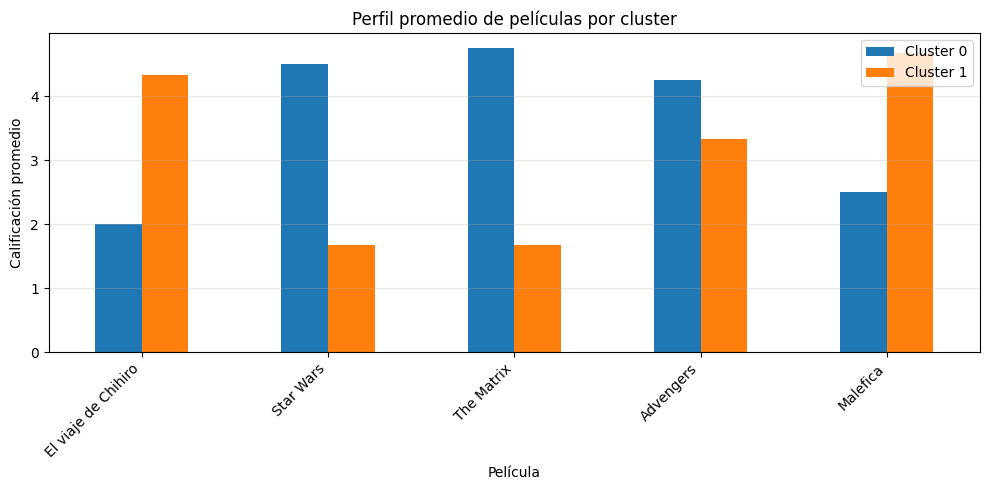

In [3]:
# Visualización del perfil medio de cada cluster
centroids_df = pd.DataFrame(
    k_means.cluster_centers_,
    columns=data.columns,
    index=[f"Cluster {i}" for i in range(k_means.n_clusters)],
)

ax = centroids_df.T.plot(kind="bar", figsize=(10, 5))
ax.set_title("Perfil promedio de películas por cluster")
ax.set_xlabel("Película")
ax.set_ylabel("Calificación promedio")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
centroids_df


In [4]:
centroids = k_means.cluster_centers_
pd.DataFrame(
    centroids,
    columns=data.columns,
    index=[f"Cluster {i}" for i in range(k_means.n_clusters)],
)


,El viaje de Chihiro,Star Wars,The Matrix,Advengers,Malefica
Cluster 0,2.000000,4.500000,4.750000,4.250000,2.500000
Cluster 1,4.333333,1.666667,1.666667,3.333333,4.666667


El grupo 0 corresponde con el perfil del usuario que prefiere películas de drama, mientras que el grupo 1 corresponde con el perfil de usuarios que prefieren películas de acción.

Estos centroides son el modelo de agrupación, por lo que pueden ser usados para predecir el perfil de un nuevo usuario de acuerdo con la calificación que le asigne a las películas. Por ejemplo, se tienen las siguientes nuevas calificaciones:

In [5]:
import numpy as np

testData = np.array([[1,4,5,4,2],[5,3,2,2,4],[4,2,3,3,1],[3,3,2,3,3],[4,5,4,1,4]])
labels = k_means.predict(testData)
labels = labels.reshape(-1,1)
usernames = np.array(['pedro','marco','liz','nico','ligia']).reshape(-1,1)
cols = peliculas.columns.tolist()
cols.append('Cluster ID')
newusers = pd.DataFrame(np.concatenate((usernames, testData, labels), axis=1),columns=cols)
newusers

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


,usuario,El viaje de Chihiro,Star Wars,The Matrix,Advengers,Malefica,Cluster ID
0,pedro,1,4,5,4,2,0
1,marco,5,3,2,2,4,1
2,liz,4,2,3,3,1,1
3,nico,3,3,2,3,3,1
4,ligia,4,5,4,1,4,0


### Ejemplo 2

In [6]:
# Importar funciones y conjunto de datos

import pandas as pd
from sklearn import cluster
#from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt


In [7]:
cluster1_data = pd.read_csv("cluster1.csv")
cluster1_data["x0"] = [float(str(i).replace(",", "")) for i in cluster1_data["x0"]]
X = cluster1_data.copy()
cluster1_data.head()


FileNotFoundError: [Errno 2] No such file or directory: 'cluster1.csv'

La función `predict` asigna clusters a los ejemplos.

In [ ]:
# Lee el archivo de puntos

n_clusters = 2
km = cluster.KMeans(n_clusters=n_clusters, n_init=10, random_state=10)
km.fit(cluster1_data)
y = km.predict(cluster1_data)
cluster1_with_labels = cluster1_data.copy()
cluster1_with_labels["cluster"] = y
cluster1_with_labels.head()


,x0,x1,cluster
0,1.064796,0.641351,0
1,8.136145,-1.729706,0
2,6.290773,10.334995,1
3,9.473930,9.286658,1
4,1.293655,2.152241,0


In [ ]:
#Lista los centroides de los clusters
km.cluster_centers_


array([[ 4.5061742 , -0.68473232],
       [ 8.01615594,  9.85357474]])

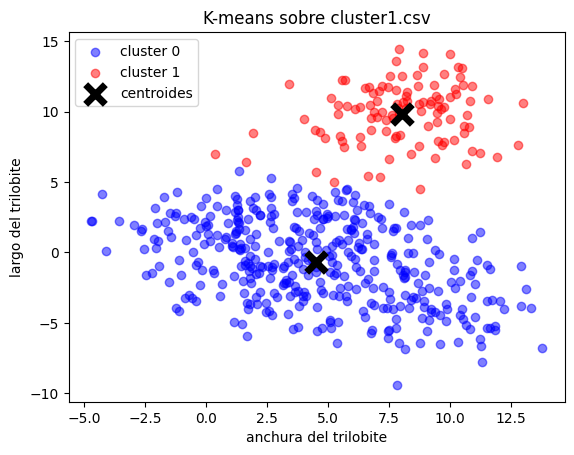

In [ ]:
import numpy as np
cmap = plt.cm.plasma

for i in np.unique(y):
    cmap = plt.cm.bwr
    col = cmap((i * 255.0 / max(n_clusters - 1, 1)).astype(int))
    Xr = cluster1_data[y == i]
    plt.scatter(Xr["x0"], Xr["x1"], color=col, label=f"cluster {i}", alpha=0.5)

plt.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    marker="x",
    lw=5,
    s=200,
    color="black",
    label="centroides",
)
plt.legend()
plt.xlabel("anchura del trilobite")
plt.ylabel("largo del trilobite")
plt.title("K-means sobre cluster1.csv")
plt.show()


### Iteración del K-means

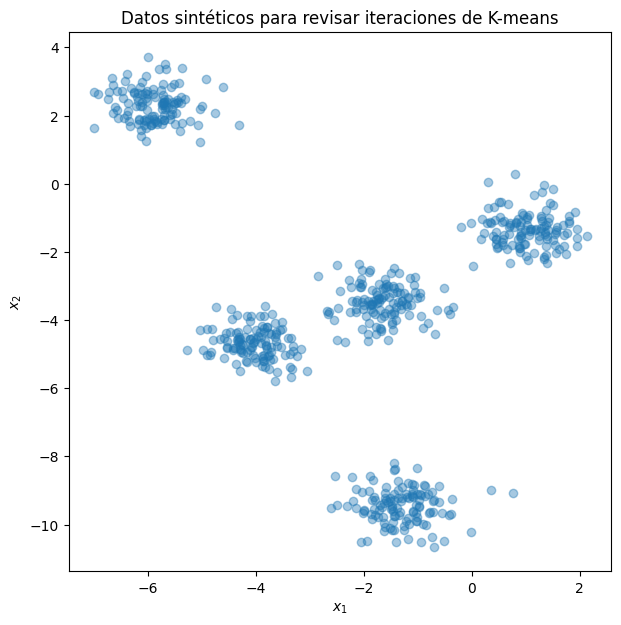

In [ ]:
from sklearn.datasets import make_blobs
np.random.seed(2)

# Creación de un dataset sintético de 5 grupos con 600 puntos
X_iter, _ = make_blobs(n_samples=600, centers=5, cluster_std=0.5)
X = X_iter.copy()
plt.figure(figsize=(7, 7))
plt.scatter(X_iter[:, 0], X_iter[:, 1], alpha=0.4)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Datos sintéticos para revisar iteraciones de K-means")
plt.show()


In [ ]:
# Definición de una función de simple K-means para ver iteraciones
from sklearn.metrics.pairwise import euclidean_distances

def simple_kmeans(X, k, iter=100):
    init_clus = np.random.choice(np.arange(X.shape[0]), replace=False, size=k)
    clusters = X[init_clus]
    preds = np.argmin(euclidean_distances(X, clusters), axis=1)
    all_clusters = [clusters.copy()]
    all_preds = [preds]

    for _ in range(iter):
        for clus in range(k):
            clusters[clus] = X[preds == clus].mean(axis=0)
        all_clusters.append(clusters.copy())
        preds = np.argmin(euclidean_distances(X, clusters), axis=1)
        all_preds.append(preds.copy())

    return all_clusters, all_preds

all_clusters, all_preds = simple_kmeans(X_iter, 5)


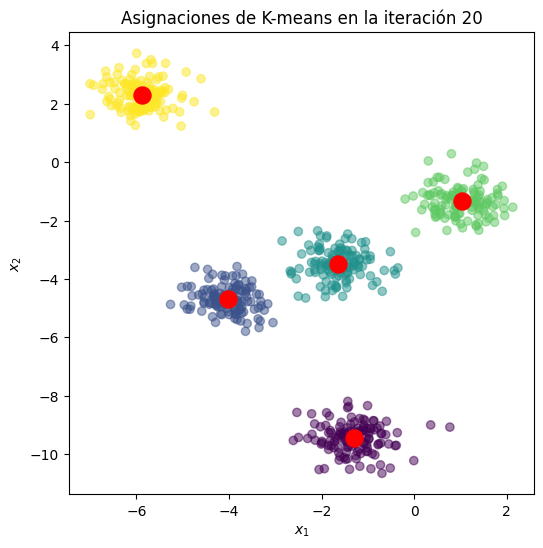

In [ ]:
# Iteración 0: se realiza la inicialización aleatoriamente y luego se reasignan puntos
#@title Iteración de K-means
iteration = 20  #@param {type:"slider", min:0, max:40, step:1}
plt.figure(figsize=(6, 6))
plt.scatter(X_iter[:, 0], X_iter[:, 1], c=all_preds[iteration], alpha=0.5)
plt.scatter(all_clusters[iteration][:, 0], all_clusters[iteration][:, 1], c="red", s=150)
plt.title(f"Asignaciones de K-means en la iteración {iteration}")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()


### Ejercicio 3

Usar el algoritmo K-means y distancia Euclidean para agrupar los siguientes puntos en 3 grupos: A1=(2,10), A2=(2,5), A3=(8,4), A4=(5,8), A5=(7,5), A6=(6,4), A7=(1,2), A8=(4,9). Asumir los centroides iniciales: A1, A4 and A7.

a) Correr una iteración y mostrar:

- Los nuevos grupos.
- Los nuevos centroides.

b) Iterar más. ¿Cuántas iteraciones se necesita para converger?

c) Mostrar gráficamente, con puntos y centroides, al converger:

- Grupos finales.
- Centroides finales.

A continuación se organizan los puntos y los centroides iniciales para trabajar el ejercicio de manera controlada, sin inicialización aleatoria.

Puntos del ejercicio


,punto,x,y
0,A1,2,10
1,A2,2,5
2,A3,8,4
3,A4,5,8
4,A5,7,5
5,A6,6,4
6,A7,1,2
7,A8,4,9


Centroides iniciales


,cluster,x,y,origen
0,C1,2.0,10.0,A1
1,C2,5.0,8.0,A4
2,C3,1.0,2.0,A7


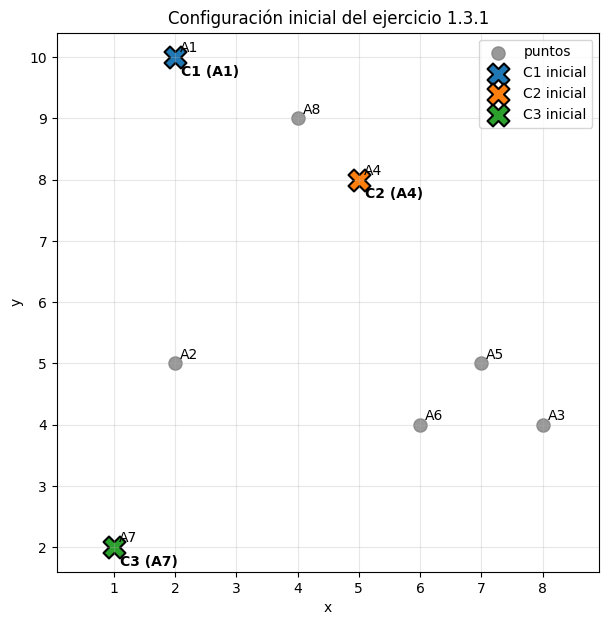

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

kmeans_ex3_points = pd.DataFrame(
    {
        "punto": ["A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8"],
        "x": [2, 2, 8, 5, 7, 6, 1, 4],
        "y": [10, 5, 4, 8, 5, 4, 2, 9],
    }
)

kmeans_ex3_initial_centroids = pd.DataFrame(
    {
        "cluster": ["C1", "C2", "C3"],
        "x": [2.0, 5.0, 1.0],
        "y": [10.0, 8.0, 2.0],
        "origen": ["A1", "A4", "A7"],
    }
)

kmeans_ex3_colors = {"C1": "tab:blue", "C2": "tab:orange", "C3": "tab:green"}

print("Puntos del ejercicio")
display(kmeans_ex3_points)
print("Centroides iniciales")
display(kmeans_ex3_initial_centroids)

plt.figure(figsize=(7, 7))
plt.scatter(kmeans_ex3_points["x"], kmeans_ex3_points["y"], color="gray", s=90, alpha=0.8, label="puntos")
for _, row in kmeans_ex3_points.iterrows():
    plt.text(row["x"] + 0.08, row["y"] + 0.08, row["punto"])

for _, row in kmeans_ex3_initial_centroids.iterrows():
    plt.scatter(
        row["x"],
        row["y"],
        marker="X",
        s=250,
        color=kmeans_ex3_colors[row["cluster"]],
        edgecolor="black",
        linewidths=1.5,
        label=f"{row['cluster']} inicial",
    )
    plt.text(row["x"] + 0.1, row["y"] - 0.3, f"{row['cluster']} ({row['origen']})", fontweight="bold")

plt.title("Configuración inicial del ejercicio 3")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.legend()
plt.axis("equal")
plt.show()


En cada iteración se calcula la distancia de cada punto a los centroides actuales, se reasignan los grupos y luego se recalculan los centroides usando el promedio de los puntos asignados.

Iteración 1
Centroides al inicio de la iteración


,cluster,x,y,origen
0,C1,2.0,10.0,A1
1,C2,5.0,8.0,A4
2,C3,1.0,2.0,A7


Asignación de puntos al centroide más cercano


,punto,x,y,dist_C1,dist_C2,dist_C3,cluster
0,A1,2,10,0.0000,3.6056,8.0623,C1
1,A2,2,5,5.0000,4.2426,3.1623,C3
2,A3,8,4,8.4853,5.0000,7.2801,C2
3,A4,5,8,3.6056,0.0000,7.2111,C2
4,A5,7,5,7.0711,3.6056,6.7082,C2
5,A6,6,4,7.2111,4.1231,5.3852,C2
6,A7,1,2,8.0623,7.2111,0.0000,C3
7,A8,4,9,2.2361,1.4142,7.6158,C2


Grupos resultantes


,cluster,puntos,cantidad
0,C1,A1,1
1,C2,"A3, A4, A5, A6, A8",5
2,C3,"A2, A7",2


Nuevos centroides


,cluster,x,y,origen
0,C1,2.0,10.0,A1
1,C2,6.0,6.0,"A3, A4, A5, A6, A8"
2,C3,1.5,3.5,"A2, A7"


Visualización de la iteración


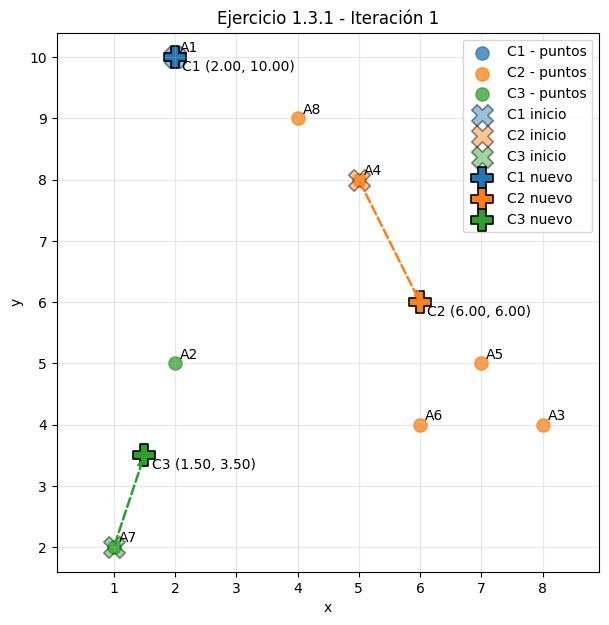

------------------------------------------------------------------------------------------
Iteración 2
Centroides al inicio de la iteración


,cluster,x,y,origen
0,C1,2.0,10.0,A1
1,C2,6.0,6.0,"A3, A4, A5, A6, A8"
2,C3,1.5,3.5,"A2, A7"


Asignación de puntos al centroide más cercano


,punto,x,y,dist_C1,dist_C2,dist_C3,cluster
0,A1,2,10,0.0000,5.6569,6.5192,C1
1,A2,2,5,5.0000,4.1231,1.5811,C3
2,A3,8,4,8.4853,2.8284,6.5192,C2
3,A4,5,8,3.6056,2.2361,5.7009,C2
4,A5,7,5,7.0711,1.4142,5.7009,C2
5,A6,6,4,7.2111,2.0000,4.5277,C2
6,A7,1,2,8.0623,6.4031,1.5811,C3
7,A8,4,9,2.2361,3.6056,6.0415,C1


Grupos resultantes


,cluster,puntos,cantidad
0,C1,"A1, A8",2
1,C2,"A3, A4, A5, A6",4
2,C3,"A2, A7",2


Nuevos centroides


,cluster,x,y,origen
0,C1,3.0,9.50,"A1, A8"
1,C2,6.5,5.25,"A3, A4, A5, A6"
2,C3,1.5,3.50,"A2, A7"


Visualización de la iteración


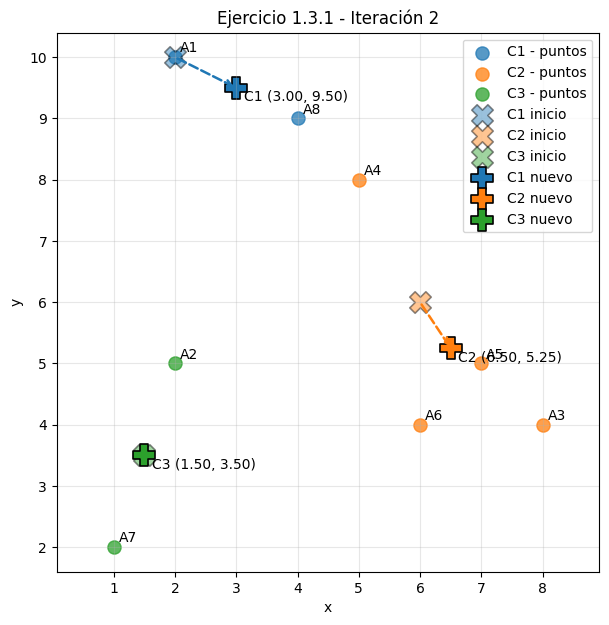

------------------------------------------------------------------------------------------
Iteración 3
Centroides al inicio de la iteración


,cluster,x,y,origen
0,C1,3.0,9.50,"A1, A8"
1,C2,6.5,5.25,"A3, A4, A5, A6"
2,C3,1.5,3.50,"A2, A7"


Asignación de puntos al centroide más cercano


,punto,x,y,dist_C1,dist_C2,dist_C3,cluster
0,A1,2,10,1.1180,6.5431,6.5192,C1
1,A2,2,5,4.6098,4.5069,1.5811,C3
2,A3,8,4,7.4330,1.9526,6.5192,C2
3,A4,5,8,2.5000,3.1325,5.7009,C1
4,A5,7,5,6.0208,0.5590,5.7009,C2
5,A6,6,4,6.2650,1.3463,4.5277,C2
6,A7,1,2,7.7621,6.3885,1.5811,C3
7,A8,4,9,1.1180,4.5069,6.0415,C1


Grupos resultantes


,cluster,puntos,cantidad
0,C1,"A1, A4, A8",3
1,C2,"A3, A5, A6",3
2,C3,"A2, A7",2


Nuevos centroides


,cluster,x,y,origen
0,C1,3.6667,9.0000,"A1, A4, A8"
1,C2,7.0000,4.3333,"A3, A5, A6"
2,C3,1.5000,3.5000,"A2, A7"


Visualización de la iteración


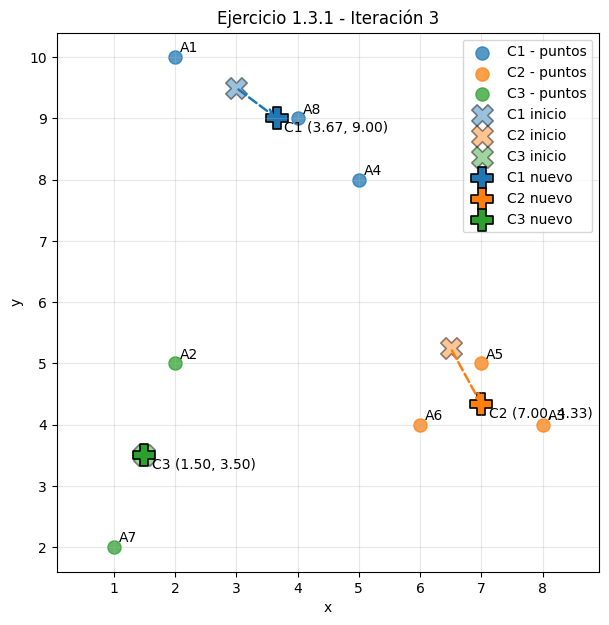

------------------------------------------------------------------------------------------
Iteración 4
Centroides al inicio de la iteración


,cluster,x,y,origen
0,C1,3.6667,9.0000,"A1, A4, A8"
1,C2,7.0000,4.3333,"A3, A5, A6"
2,C3,1.5000,3.5000,"A2, A7"


Asignación de puntos al centroide más cercano


,punto,x,y,dist_C1,dist_C2,dist_C3,cluster
0,A1,2,10,1.9437,7.5572,6.5192,C1
1,A2,2,5,4.3333,5.0442,1.5811,C3
2,A3,8,4,6.6165,1.0541,6.5192,C2
3,A4,5,8,1.6667,4.1767,5.7009,C1
4,A5,7,5,5.2068,0.6667,5.7009,C2
5,A6,6,4,5.5176,1.0541,4.5277,C2
6,A7,1,2,7.4907,6.4377,1.5811,C3
7,A8,4,9,0.3333,5.5478,6.0415,C1


Grupos resultantes


,cluster,puntos,cantidad
0,C1,"A1, A4, A8",3
1,C2,"A3, A5, A6",3
2,C3,"A2, A7",2


Nuevos centroides


,cluster,x,y,origen
0,C1,3.6667,9.0000,"A1, A4, A8"
1,C2,7.0000,4.3333,"A3, A5, A6"
2,C3,1.5000,3.5000,"A2, A7"


Visualización de la iteración


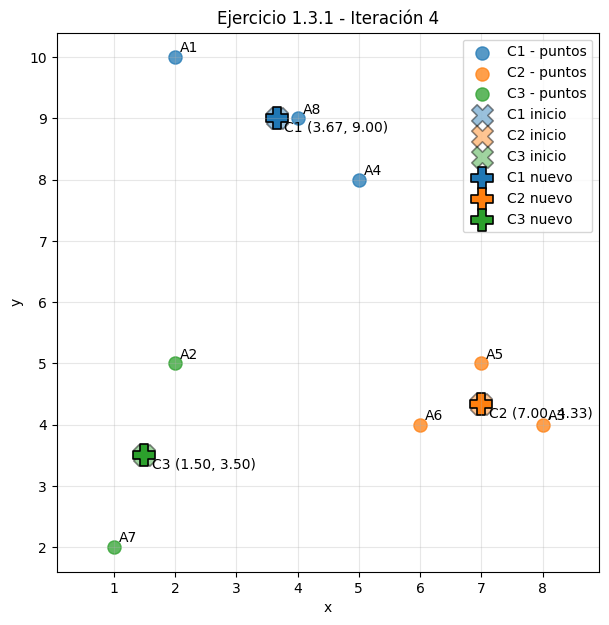

Convergencia detectada en esta iteración.
------------------------------------------------------------------------------------------


In [ ]:
def assign_to_fixed_centroids(points_df, centroids_df):
    point_coords = points_df[["x", "y"]].to_numpy(dtype=float)
    centroid_coords = centroids_df[["x", "y"]].to_numpy(dtype=float)
    distance_matrix = np.sqrt(((point_coords[:, None, :] - centroid_coords[None, :, :]) ** 2).sum(axis=2))

    assignment_idx = distance_matrix.argmin(axis=1)
    assignments_df = points_df.copy()

    for idx, cluster_name in enumerate(centroids_df["cluster"]):
        assignments_df[f"dist_{cluster_name}"] = distance_matrix[:, idx]

    assignments_df["cluster"] = [centroids_df.loc[idx, "cluster"] for idx in assignment_idx]
    return assignments_df, assignment_idx


def summarize_groups(assignments_df, centroids_df):
    rows = []
    for cluster_name in centroids_df["cluster"]:
        names = assignments_df.loc[assignments_df["cluster"] == cluster_name, "punto"].tolist()
        rows.append(
            {
                "cluster": cluster_name,
                "puntos": ", ".join(names),
                "cantidad": len(names),
            }
        )
    return pd.DataFrame(rows)


def recompute_centroids(points_df, assignments_df, centroids_df):
    rows = []
    for _, centroid_row in centroids_df.iterrows():
        cluster_name = centroid_row["cluster"]
        subset = assignments_df[assignments_df["cluster"] == cluster_name]
        if subset.empty:
            rows.append(centroid_row.to_dict())
            continue
        rows.append(
            {
                "cluster": cluster_name,
                "x": subset["x"].mean(),
                "y": subset["y"].mean(),
                "origen": ", ".join(subset["punto"].tolist()),
            }
        )
    return pd.DataFrame(rows)


def plot_kmeans_ex3_step(step, colors):
    fig, ax = plt.subplots(figsize=(7, 7))
    assignments_df = step["assignments"]
    centroids_in = step["centroids_in"]
    centroids_out = step["centroids_out"]

    for cluster_name, cluster_points in assignments_df.groupby("cluster"):
        ax.scatter(
            cluster_points["x"],
            cluster_points["y"],
            s=90,
            color=colors[cluster_name],
            alpha=0.75,
            label=f"{cluster_name} - puntos",
        )
        for _, row in cluster_points.iterrows():
            ax.text(row["x"] + 0.08, row["y"] + 0.08, row["punto"])

    for _, row in centroids_in.iterrows():
        ax.scatter(
            row["x"],
            row["y"],
            marker="X",
            s=240,
            color=colors[row["cluster"]],
            edgecolor="black",
            linewidths=1.2,
            alpha=0.45,
            label=f"{row['cluster']} inicio",
        )

    for _, row in centroids_out.iterrows():
        ax.scatter(
            row["x"],
            row["y"],
            marker="P",
            s=240,
            color=colors[row["cluster"]],
            edgecolor="black",
            linewidths=1.2,
            label=f"{row['cluster']} nuevo",
        )
        ax.text(row["x"] + 0.12, row["y"] - 0.22, f"{row['cluster']} ({row['x']:.2f}, {row['y']:.2f})")

    for cluster_name in centroids_in["cluster"]:
        start = centroids_in.loc[centroids_in["cluster"] == cluster_name, ["x", "y"]].iloc[0]
        end = centroids_out.loc[centroids_out["cluster"] == cluster_name, ["x", "y"]].iloc[0]
        ax.annotate(
            "",
            xy=(end["x"], end["y"]),
            xytext=(start["x"], start["y"]),
            arrowprops=dict(arrowstyle="->", linestyle="--", color=colors[cluster_name], lw=1.8),
        )

    ax.set_title(f"Ejercicio 3 - Iteración {step['iteration']}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.3)
    ax.axis("equal")

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc="best")
    plt.show()


def run_kmeans_exercise(points_df, initial_centroids_df, max_iter=10):
    history = []
    current_centroids = initial_centroids_df.copy()
    previous_assignment = None

    for iteration in range(1, max_iter + 1):
        assignments_df, assignment_idx = assign_to_fixed_centroids(points_df, current_centroids)
        groups_df = summarize_groups(assignments_df, current_centroids)
        updated_centroids = recompute_centroids(points_df, assignments_df, current_centroids)

        same_assignment = previous_assignment is not None and np.array_equal(assignment_idx, previous_assignment)
        same_centroids = np.allclose(
            current_centroids[["x", "y"]].to_numpy(dtype=float),
            updated_centroids[["x", "y"]].to_numpy(dtype=float),
        )

        history.append(
            {
                "iteration": iteration,
                "centroids_in": current_centroids.copy(),
                "assignments": assignments_df.copy(),
                "groups": groups_df.copy(),
                "centroids_out": updated_centroids.copy(),
                "converged": same_assignment or same_centroids,
            }
        )

        if same_assignment or same_centroids:
            break

        previous_assignment = assignment_idx.copy()
        current_centroids = updated_centroids.copy()

    return history


kmeans_ex3_history = run_kmeans_exercise(
    kmeans_ex3_points,
    kmeans_ex3_initial_centroids,
)

for step in kmeans_ex3_history:
    print(f"Iteración {step['iteration']}")
    print("Centroides al inicio de la iteración")
    display(step["centroids_in"].round(4))

    print("Asignación de puntos al centroide más cercano")
    display(
        step["assignments"][["punto", "x", "y", "dist_C1", "dist_C2", "dist_C3", "cluster"]].round(4)
    )

    print("Grupos resultantes")
    display(step["groups"])

    print("Nuevos centroides")
    display(step["centroids_out"].round(4))

    print("Visualización de la iteración")
    plot_kmeans_ex3_step(step, kmeans_ex3_colors)

    if step["converged"]:
        print("Convergencia detectada en esta iteración.")

    print("-" * 90)


La siguiente celda resume explícitamente lo pedido en los incisos **a**, **b** y **c**, y además muestra la visualización final del agrupamiento al converger.

Respuesta inciso a): primera iteración


,cluster,puntos,cantidad
0,C1,A1,1
1,C2,"A3, A4, A5, A6, A8",5
2,C3,"A2, A7",2


,cluster,x,y,origen
0,C1,2.0,10.0,A1
1,C2,6.0,6.0,"A3, A4, A5, A6, A8"
2,C3,1.5,3.5,"A2, A7"


Respuesta inciso b): convergencia
K-means converge después de 3 actualizaciones de centroides y 4 evaluaciones de asignación si se cuenta la verificación final de estabilidad.
Respuesta inciso c): solución final


,cluster,puntos,cantidad
0,C1,"A1, A4, A8",3
1,C2,"A3, A5, A6",3
2,C3,"A2, A7",2


,cluster,x,y,origen
0,C1,3.6667,9.0000,"A1, A4, A8"
1,C2,7.0000,4.3333,"A3, A5, A6"
2,C3,1.5000,3.5000,"A2, A7"


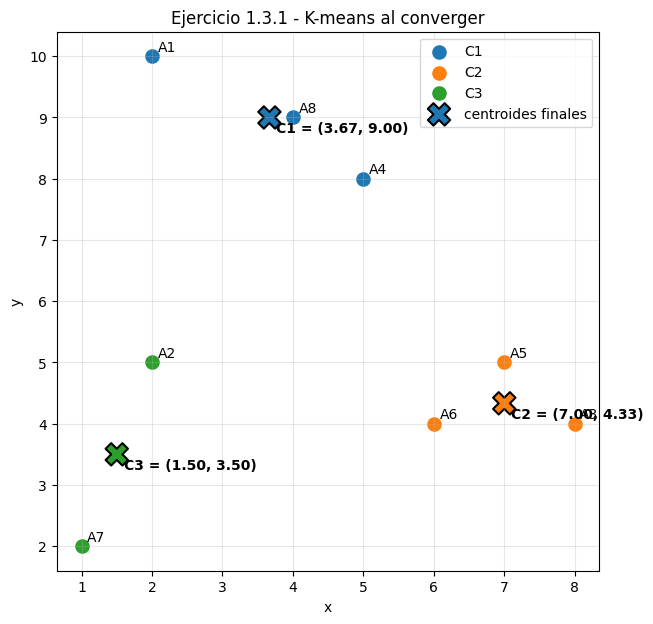

In [ ]:
first_step = kmeans_ex3_history[0]
final_step = kmeans_ex3_history[-1]

centroid_updates = sum(
    not np.allclose(
        step["centroids_in"][["x", "y"]].to_numpy(dtype=float),
        step["centroids_out"][["x", "y"]].to_numpy(dtype=float),
    )
    for step in kmeans_ex3_history
)

print("Respuesta inciso a): primera iteración")
display(first_step["groups"])
display(first_step["centroids_out"].round(4))

print("Respuesta inciso b): convergencia")
print(
    f"K-means converge después de {centroid_updates} actualizaciones de centroides "
    f"y {len(kmeans_ex3_history)} evaluaciones de asignación si se cuenta la verificación final de estabilidad."
)

print("Respuesta inciso c): solución final")
display(final_step["groups"])
display(final_step["centroids_out"].round(4))

final_assignments = final_step["assignments"][["punto", "x", "y", "cluster"]].copy()
final_centroids = final_step["centroids_out"].copy()
colors = {"C1": "tab:blue", "C2": "tab:orange", "C3": "tab:green"}

plt.figure(figsize=(7, 7))
for cluster_name, cluster_points in final_assignments.groupby("cluster"):
    plt.scatter(
        cluster_points["x"],
        cluster_points["y"],
        s=90,
        color=colors[cluster_name],
        label=cluster_name,
    )
    for _, row in cluster_points.iterrows():
        plt.text(row["x"] + 0.08, row["y"] + 0.08, row["punto"])

plt.scatter(
    final_centroids["x"],
    final_centroids["y"],
    marker="X",
    s=260,
    c=[colors[name] for name in final_centroids["cluster"]],
    edgecolor="black",
    linewidths=1.5,
    label="centroides finales",
)

for _, row in final_centroids.iterrows():
    plt.text(
        row["x"] + 0.1,
        row["y"] - 0.25,
        f"{row['cluster']} = ({row['x']:.2f}, {row['y']:.2f})",
        fontweight="bold",
    )

plt.title("Ejercicio 3 - K-means al converger")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


- En la **primera iteración**, `A1` queda sola en `C1`, `A2` y `A7` quedan en `C3`, y el resto de puntos quedan en `C2`.
- Después de seguir actualizando centroides, la solución se estabiliza con los grupos:
  - `C1 = {A1, A4, A8}`
  - `C2 = {A3, A5, A6}`
  - `C3 = {A2, A7}`
- Los centroides finales son aproximadamente:
  - `C1 = (3.67, 9.00)`
  - `C2 = (7.00, 4.33)`
  - `C3 = (1.50, 3.50)`
- Si se cuentan solo las **actualizaciones efectivas de centroides**, el algoritmo converge en **3 iteraciones**.

### Consulta

1. ¿En qué consiste la inicialización **K-means++**?

K-means++ es una estrategia para escoger los centroides iniciales de forma más cuidadosa que una selección completamente aleatoria. Primero elige un punto inicial y luego selecciona los siguientes centroides con mayor probabilidad cuando están lejos de los centroides ya escogidos. Esto ayuda a iniciar el algoritmo con centros más separados, reduce el riesgo de malos mínimos locales y normalmente mejora la estabilidad del resultado.

2. ¿En qué consiste **Mini Batch K-Means**?

Mini Batch K-Means es una variante de K-means que no usa todos los datos en cada actualización, sino pequeños subconjuntos o lotes aleatorios. Con cada lote actualiza los centroides de manera aproximada. Por esta razón suele ser más rápido y consume menos memoria en datasets grandes, aunque el resultado puede ser un poco menos preciso que el K-means tradicional.

## Determinar el número de k

La distancia intra-cluster mide qué tan compacto es cada cluster. Existen varias medidas intra-cluster; una de ellas se define como:

$$\sum_{i=0}^{n}\min_{\mu_j \in C}(||x_i - \mu_j||^2)$$

K-means minimiza esta medida y la utiliza como criterio de calidad del agrupamiento. El método consiste en ejecutar varias veces K-means con diferentes valores de `k` y graficar la inercia para cada uno. La gráfica resultante es una curva descendente y se busca un valor de `k` pequeño con una métrica baja. A este tipo de gráfica se le conoce como gráfica de codo o *elbow*.

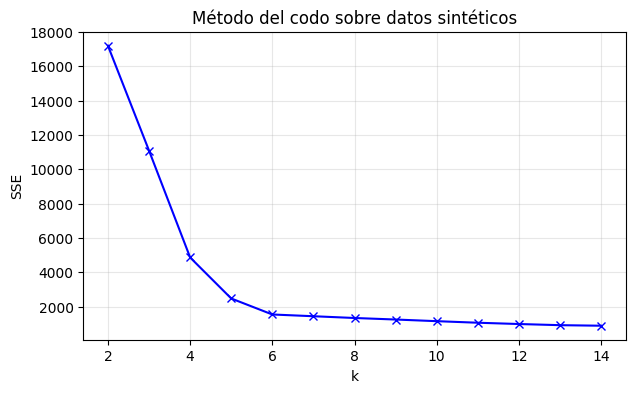

In [ ]:
# Creamos un conjunto sintético
# Se ejecuta K-means para valores de k entre 2 y 14 y se grafica la inercia con respecto al número de clusters
X_elbow, _ = make_blobs(600, cluster_std=1.2, centers=6, random_state=10)
X = X_elbow.copy()

sum_of_squared_distances = []
K = range(2, 15)
for k in K:
    km = cluster.KMeans(n_clusters=k, n_init=10, random_state=10)
    km.fit(X_elbow)
    sum_of_squared_distances.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K, sum_of_squared_distances, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Método del codo sobre datos sintéticos")
plt.grid(alpha=0.3)
plt.show()


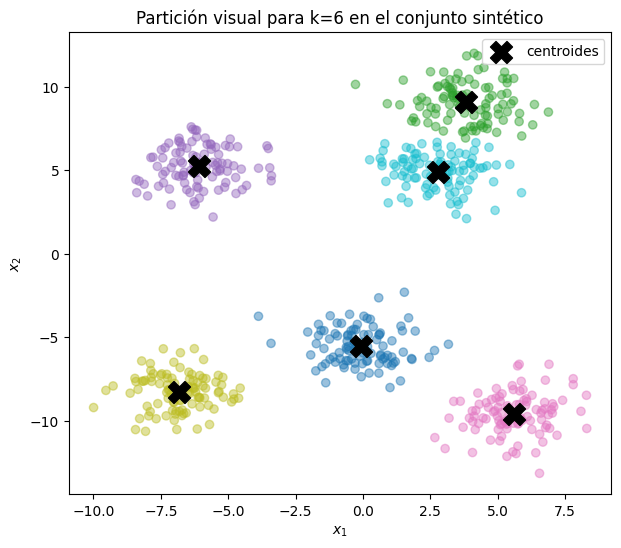

In [ ]:
# Graficamos los clusters para visualizar los centroides y comparar con la gráfica del codo
best_visual_k = 6
km_best = cluster.KMeans(n_clusters=best_visual_k, n_init=10, random_state=10)
elbow_labels = km_best.fit_predict(X_elbow)

plt.figure(figsize=(7, 6))
plt.scatter(X_elbow[:, 0], X_elbow[:, 1], c=elbow_labels, alpha=0.45, cmap="tab10")
plt.scatter(
    km_best.cluster_centers_[:, 0],
    km_best.cluster_centers_[:, 1],
    c="black",
    marker="X",
    s=250,
    label="centroides",
)
plt.title("Partición visual para k=6 en el conjunto sintético")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.show()


Ejercicios:

4. Calcular la gráfica del codo para el ejemplo 1, correspondiente a las calificaciones de películas.

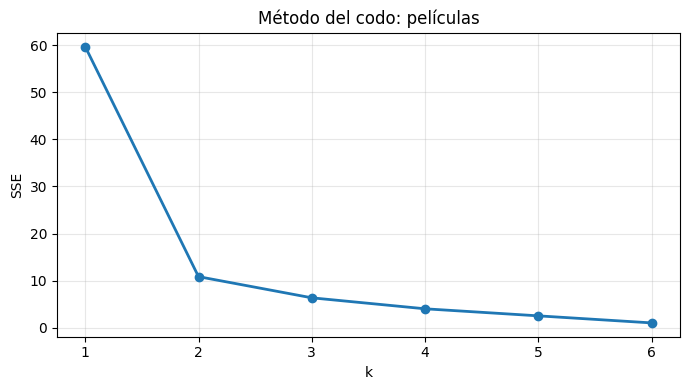

,k,sse,silhouette
0,1,59.7143,NaN
1,2,10.8333,0.6334
2,3,6.3333,0.4458
3,4,4.0000,0.2447
4,5,2.5000,0.1528
5,6,1.0000,0.0787


k sugerido por la curva: 2


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score

def evaluate_kmeans_grid(data, k_values, random_state=10):
    rows = []
    for k in k_values:
        model = cluster.KMeans(n_clusters=k, n_init=10, random_state=random_state)
        labels = model.fit_predict(data)
        rows.append(
            {
                "k": k,
                "sse": model.inertia_,
                "silhouette": np.nan if k == 1 else silhouette_score(data, labels),
            }
        )
    return pd.DataFrame(rows)

def plot_elbow_curve(results, title, ax):
    ax.plot(results["k"], results["sse"], marker="o", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.set_ylabel("SSE")
    ax.set_xticks(results["k"])
    ax.grid(alpha=0.3)

def pick_elbow_k(results):
    x = results["k"].to_numpy(dtype=float)
    y = results["sse"].to_numpy(dtype=float)
    start = np.array([x[0], y[0]])
    end = np.array([x[-1], y[-1]])
    line = end - start
    distances = []
    for xi, yi in zip(x, y):
        numerator = abs(line[0] * (start[1] - yi) - line[1] * (start[0] - xi))
        denominator = np.linalg.norm(line)
        distances.append(numerator / denominator if denominator else 0.0)
    return int(results.iloc[int(np.argmax(distances))]["k"])

movie_data = peliculas.drop("usuario", axis=1)
movie_results = evaluate_kmeans_grid(movie_data, range(1, 7))
movie_selected_k = pick_elbow_k(movie_results)

fig, ax = plt.subplots(figsize=(7, 4))
plot_elbow_curve(movie_results, "Método del codo: películas", ax)
plt.tight_layout()
plt.show()

display(movie_results.round(4))
print(f"k sugerido por la curva: {movie_selected_k}")


**Interpretación.** En este conjunto pequeño la mayor reducción del SSE ocurre al pasar de `k=1` a `k=2`. A partir de ese punto la curva empieza a aplanarse, por lo que `k=2` es una elección razonable para separar dos perfiles generales de preferencia.


5. Entrenar un modelo K-means con un conjunto de datos en dos dimensiones, realizar una exploración del parámetro `k`, seleccionar un valor apropiado usando el método del codo y argumentar la decisión.

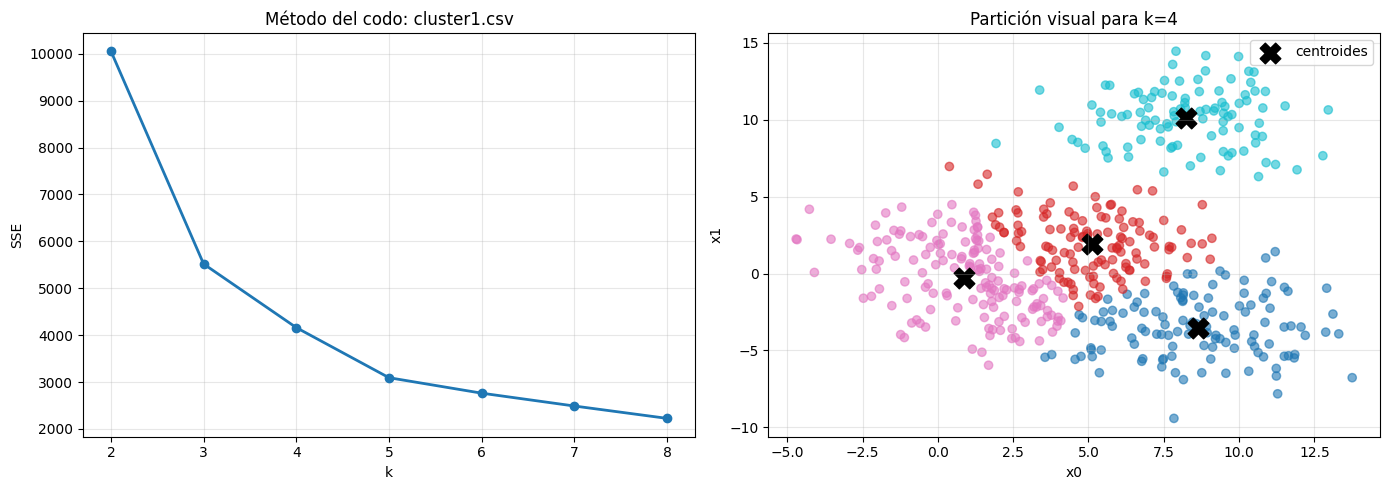

,k,sse,silhouette
0,2,10056.7419,0.5218
1,3,5517.7738,0.4620
2,4,4160.5365,0.4130
3,5,3092.0822,0.4424
4,6,2761.9131,0.3997
5,7,2488.1111,0.3849
6,8,2224.6022,0.3360


k sugerido por la curva y usado en la visualización final: 4


In [ ]:
cluster1_results = evaluate_kmeans_grid(cluster1_data, range(2, 9))
cluster1_selected_k = pick_elbow_k(cluster1_results)

cluster1_model = cluster.KMeans(
    n_clusters=cluster1_selected_k,
    n_init=10,
    random_state=10,
)
cluster1_labels = cluster1_model.fit_predict(cluster1_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_elbow_curve(cluster1_results, "Método del codo: cluster1.csv", axes[0])

axes[1].scatter(
    cluster1_data["x0"],
    cluster1_data["x1"],
    c=cluster1_labels,
    alpha=0.6,
    cmap="tab10",
)
axes[1].scatter(
    cluster1_model.cluster_centers_[:, 0],
    cluster1_model.cluster_centers_[:, 1],
    c="black",
    marker="X",
    s=220,
    label="centroides",
)
axes[1].set_title(f"Partición visual para k={cluster1_selected_k}")
axes[1].set_xlabel("x0")
axes[1].set_ylabel("x1")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(cluster1_results.round(4))
print(f"k sugerido por la curva y usado en la visualización final: {cluster1_selected_k}")


**Interpretación.** La decisión final debe tomarse observando dónde la reducción del SSE deja de ser tan pronunciada. En una ejecución típica de este dataset el codo aparece cerca de `k=3`, y esa elección además produce una separación visual clara en el plano.


6. Aplicar el algoritmo K-means al conjunto de datos Iris, sin la clase, para `k = 2, 3, 4, 5, 6, 7, 8`. Dibujar la gráfica de codo basada en el SSE y explicar los resultados.

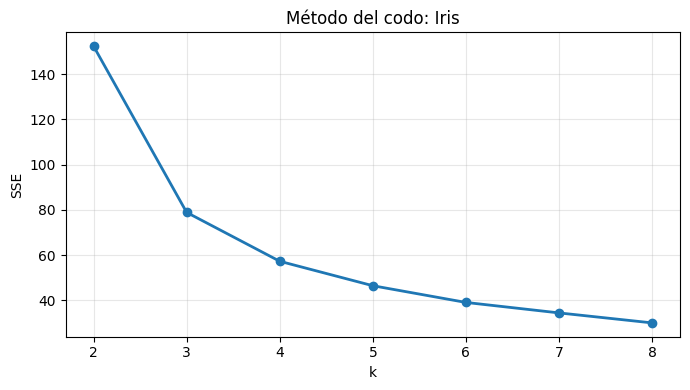

,k,sse,silhouette
0,2,152.3480,0.6810
1,3,78.8514,0.5528
2,4,57.2560,0.4975
3,5,46.4462,0.4887
4,6,39.0550,0.3665
5,7,34.4278,0.3520
6,8,30.0144,0.3539


k sugerido por la curva: 4


In [ ]:
iris = load_iris(as_frame=True)
iris_data = iris.data.copy()
iris_results = evaluate_kmeans_grid(iris_data, range(2, 9))
iris_selected_k = pick_elbow_k(iris_results)

fig, ax = plt.subplots(figsize=(7, 4))
plot_elbow_curve(iris_results, "Método del codo: Iris", ax)
plt.tight_layout()
plt.show()

display(iris_results.round(4))
print(f"k sugerido por la curva: {iris_selected_k}")


**Interpretación.** En Iris suele observarse un cambio importante alrededor de `k=3`, lo cual coincide con la existencia de tres especies en el conjunto original. Sin embargo, la curva no siempre muestra un codo perfectamente agudo porque algunas observaciones se solapan en el espacio de variables.


- En **películas** el dataset es pequeño y `k=2` resume bien dos perfiles principales.
- En **cluster1.csv** la inspección visual en 2D complementa la curva del codo y ayuda a justificar el valor seleccionado.
- En **Iris** el método del codo sugiere un valor cercano a `k=3`, aunque con una transición más suave por el solapamiento entre especies.

## Hierarchical Clustering

### Ejemplo 1

Usaremos un dataset de vertebrados, ejemplo de TAN, usado para clasificación. Se ejecutarán los tres algoritmos clásicos de agrupación jerárquica aglomerativa: single link (MIN), complete link (MAX) y group average, usando la librería `scipy` de Python. También se incluye Ward para comparar.

In [ ]:
import pandas as pd
data = pd.read_csv('vertebrate.csv',header='infer')
data

FileNotFoundError: [Errno 2] No such file or directory: 'vertebrate.csv'

In [ ]:
# importamos las librerías
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
%matplotlib inline

names = data['Name']
Y = data['Class']
# Se eliminan la columna de nombre y la clase
X = data.drop(['Name','Class'],axis=1)

**Single Link (MIN)**

In [ ]:
Z = hierarchy.single(X)
dn = hierarchy.dendrogram(Z,labels=names.tolist(), orientation='right')

**Complete Link (MAX)**

In [ ]:
Z = hierarchy.complete(X)
dn = hierarchy.dendrogram(Z,labels=names.tolist(),orientation='right')

**Average - Promedio**

In [ ]:
Z = hierarchy.average(X)
dn = hierarchy.dendrogram(Z,labels=names.tolist(),orientation='right')

**Ward**

In [ ]:
Z = hierarchy.ward(X)
dn = hierarchy.dendrogram(Z,labels=names.tolist(),orientation='right')

### Ejercicio 1

¿Qué concluye de los cuatro métodos con respecto al conjunto de datos usado?

- **Single link (MIN)** es el método más sensible al efecto de encadenamiento: basta con que dos animales compartan algunas características para que se unan temprano, aunque el grupo final no sea tan compacto.
- **Complete link (MAX)** produce clusters más cerrados y homogéneos, porque exige que todos los elementos de un grupo permanezcan relativamente cercanos entre sí.
- **Average link** funciona como un punto medio entre los dos anteriores: reduce el encadenamiento del enlace simple, pero sin ser tan estricto como complete link.
- **Ward** suele dar la partición más balanceada e interpretable en este dataset, porque busca minimizar la variación interna y tiende a separar mejor grupos naturales como peces, mamíferos o aves.
- En conjunto, los cuatro métodos muestran una estructura jerárquica similar, pero cambian en la forma en que fusionan clases intermedias como reptiles y anfibios, que comparten varios atributos binarios.

### Ejercicio 2

Dado un conjunto de ejemplos categóricos de 5 dimensiones:

In [ ]:
from scipy.spatial import distance

X = np.array([
              [ 1,0,1,1,0],
              [ 1,1,0,1,0],
              [ 0,0,1,1,0],
              [ 0,1,0,1,0],
              [ 1,0,1,1,0],
              [ 0,1,1,0,0],
             ])
X

a) Aplicar agrupamiento jerárquico aglomerativo usando:

- Medida intercluster enlace simple (single link o MIN) basado en el coeficiente de Rao. Diagramar el dendrograma.
- Medida intercluster enlace completo (complete link o MAX) basado en coeficiente de correspondencia simple CCS (SMC, *Simple Matching Coefficient*). Diagramar el dendrograma.

b) ¿Es posible usar el método de Ward? Explique.

Respuesta:

In [ ]:
from scipy.spatial.distance import squareform

row_labels = [f"E{i}" for i in range(1, X.shape[0] + 1)]

def rao_distance(a, b):
    return np.mean(a != b)

def smc_similarity(a, b):
    return np.mean(a == b)

n = X.shape[0]
rao_matrix = np.zeros((n, n))
smc_distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        rao_matrix[i, j] = rao_distance(X[i], X[j])
        smc_distance_matrix[i, j] = 1 - smc_similarity(X[i], X[j])

rao_df = pd.DataFrame(rao_matrix, index=row_labels, columns=row_labels)
smc_df = pd.DataFrame(smc_distance_matrix, index=row_labels, columns=row_labels)
print("Matriz de distancia de Rao")
display(rao_df.round(2))
print("Matriz de distancia derivada de SMC")
display(smc_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

Z_rao = hierarchy.linkage(squareform(rao_matrix, checks=False), method="single")
hierarchy.dendrogram(Z_rao, labels=row_labels, ax=axes[0])
axes[0].set_title("Single Link con distancia de Rao")
axes[0].set_ylabel("Distancia")

Z_smc = hierarchy.linkage(squareform(smc_distance_matrix, checks=False), method="complete")
hierarchy.dendrogram(Z_smc, labels=row_labels, ax=axes[1])
axes[1].set_title("Complete Link con distancia basada en SMC")
axes[1].set_ylabel("Distancia")

plt.tight_layout()
plt.show()


El método de Ward minimiza la varianza intra-cluster y, por construcción, está pensado para variables numéricas con una noción euclidiana de centroide y suma de cuadrados. Por eso no es adecuado aplicarlo directamente sobre atributos categóricos o binarios usando coeficientes como Rao o SMC sin una transformación numérica adicional.

- Con la distancia de **Rao** y **single link**, los pares más parecidos se fusionan primero; en particular, `E1` y `E5` son idénticos y por eso se unen con distancia `0`.
- El criterio de **single link** favorece cadenas de elementos similares, de modo que un ejemplo puede entrar a un cluster por parecerse mucho a un solo miembro del grupo.
- Con la distancia derivada de **SMC** y **complete link**, la unión de grupos es más conservadora: se forman clusters más compactos porque se controla la peor disimilitud entre elementos.
- La comparación entre ambos dendrogramas muestra que la elección de la métrica y del enlace cambia la forma del árbol, incluso usando exactamente los mismos ejemplos.
- **Ward** no se recomienda aquí de forma directa porque trabaja mejor con variables numéricas y una noción de varianza intra-cluster, no con disimilitudes categóricas como Rao o SMC.

### Ejercicio 3

Usar el conjunto de datos [“Perfume Data Data Set”](https://archive.ics.uci.edu/ml/datasets/Perfume+Data#) del repositorio UCI (Machine Learning) para:

- Aplicar los algoritmos `single link`, `complete link`, `average link` y `Ward`. Graficar dendrogramas y explicar resultados.
- Aplicar PCA y nuevamente aplicar los algoritmos y graficar los dendrogramas.

El repositorio UCI indica que el dataset contiene mediciones de olor de **20 perfumes**, tomadas con un sensor OMX-GR durante **28 segundos**. Para aplicar clustering jerárquico, cada perfume se representa como un vector de 28 mediciones.

In [10]:
from io import BytesIO
from zipfile import ZipFile
from urllib.request import urlopen

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

perfume_url = "https://archive.ics.uci.edu/static/public/303/perfume+data.zip"
perfume_names = [
    "ajayeb", "ajmal", "amreaj", "aood", "asgar_ali",
    "bukhoor", "burberry", "dehenalaod", "junaid", "kausar",
    "rose", "solidmusk", "TeaTreeOil", "raspberry", "RoseMusk",
    "strawberry", "constrected2", "carolina_herrera",
    "oudh_ma'alattar", "constrected1",
]

with urlopen(perfume_url) as response:
    perfume_zip = ZipFile(BytesIO(response.read()))

perfume_zip.namelist()


['testing in rows.xls', 'perfume_data.xlsx']

In [11]:
with perfume_zip.open("perfume_data.xlsx") as perfume_file:
    perfume_raw = pd.read_excel(perfume_file, header=None)

perfume_raw = perfume_raw.dropna(how="all").dropna(axis=1, how="all")
perfume_numeric = perfume_raw.apply(pd.to_numeric, errors="coerce")
perfume_numeric = perfume_numeric.dropna(how="all").dropna(axis=1, how="all")

if perfume_numeric.shape[0] == len(perfume_names):
    perfume_profiles = perfume_numeric.copy()
elif perfume_numeric.shape[1] == len(perfume_names):
    perfume_profiles = perfume_numeric.T.copy()
else:
    raise ValueError(
        "No se pudo identificar la orientación del dataset de perfumes: "
        f"forma encontrada {perfume_numeric.shape}"
    )

perfume_profiles.index = perfume_names
perfume_profiles.columns = [
    f"segundo_{i}" for i in range(1, perfume_profiles.shape[1] + 1)
]

print(f"Forma final del dataset: {perfume_profiles.shape[0]} perfumes x {perfume_profiles.shape[1]} mediciones")
display(perfume_profiles.head())
perfume_profiles.shape

Forma final del dataset: 20 perfumes x 28 mediciones


,segundo_1,segundo_2,segundo_3,segundo_4,segundo_5,segundo_6,segundo_7,segundo_8,segundo_9,segundo_10,...,segundo_19,segundo_20,segundo_21,segundo_22,segundo_23,segundo_24,segundo_25,segundo_26,segundo_27,segundo_28
ajayeb,64558,64556,64543,64543,64541,64543,64543,64541,64541,64541,...,64541,64541,64541,64541,64541,64541,64528,64528,64528,64528
ajmal,60502,60489,61485,60487,61485,61513,60515,60500,60500,60487,...,60472,60472,60461,61470,60487,60487,61485,60487,60472,60472
amreaj,57040,57040,57040,58041,58041,58041,58041,57042,57042,58043,...,58041,58041,58041,58041,58041,58041,58041,58041,58041,58041
aood,71083,72087,71091,71095,71099,72103,71099,72099,72099,73098,...,72095,71095,71095,72103,71103,71103,71103,72103,72103,72098
asgar_ali,68209,68209,68216,68216,68223,68223,68223,68223,68230,68230,...,68230,67224,67217,67217,68223,68223,68223,68223,68223,68230


(20, 28)

Antes de construir los dendrogramas se estandarizan las 28 mediciones, para que la comparación dependa del patrón relativo de respuesta del sensor y no solo de la escala absoluta.

In [ ]:
scaler = StandardScaler()
perfume_scaled = scaler.fit_transform(perfume_profiles)

linkage_methods = {
    "Single link": "single",
    "Complete link": "complete",
    "Average link": "average",
    "Ward": "ward",
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for ax, (title, method) in zip(axes, linkage_methods.items()):
    Z = hierarchy.linkage(perfume_scaled, method=method, metric="euclidean")
    hierarchy.dendrogram(
        Z,
        labels=perfume_profiles.index,
        leaf_rotation=90,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_ylabel("Distancia")

plt.tight_layout()
plt.show()


PCA reduce las 28 mediciones a componentes principales que concentran la mayor parte de la variabilidad. Esto permite visualizar los perfumes en dos dimensiones y repetir el análisis jerárquico sobre una representación más compacta.

In [ ]:
pca = PCA(n_components=2, random_state=42)
perfume_pca = pca.fit_transform(perfume_scaled)

perfume_pca_df = pd.DataFrame(
    perfume_pca,
    index=perfume_profiles.index,
    columns=["PC1", "PC2"],
)

print("Varianza explicada por componente:")
display(
    pd.Series(
        pca.explained_variance_ratio_,
        index=["PC1", "PC2"],
        name="varianza_explicada",
    ).round(3)
)

plt.figure(figsize=(8, 6))
plt.scatter(perfume_pca_df["PC1"], perfume_pca_df["PC2"], s=80)

for perfume, row in perfume_pca_df.iterrows():
    plt.text(row["PC1"] + 0.03, row["PC2"] + 0.03, perfume, fontsize=9)

plt.title("Perfumes proyectados con PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()


Después de aplicar PCA, se repiten los dendrogramas con los mismos cuatro métodos para comparar si la estructura de grupos se conserva en la representación reducida.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for ax, (title, method) in zip(axes, linkage_methods.items()):
    Z = hierarchy.linkage(perfume_pca, method=method, metric="euclidean")
    hierarchy.dendrogram(
        Z,
        labels=perfume_profiles.index,
        leaf_rotation=90,
        ax=ax,
    )
    ax.set_title(f"{title} sobre PCA")
    ax.set_ylabel("Distancia")

plt.tight_layout()
plt.show()


- **Single link** tiende a unir perfumes por el vecino más cercano; por eso puede formar cadenas cuando varios perfiles comparten similitudes parciales.
- **Complete link** exige que todos los perfumes dentro de un grupo sean cercanos entre sí, de modo que produce clusters más compactos y conservadores.
- **Average link** suele quedar en un punto intermedio, porque usa la distancia promedio entre elementos de dos grupos.
- **Ward** busca minimizar la variabilidad interna de los clusters y normalmente produce particiones más balanceadas cuando las variables son numéricas y están estandarizadas.
- Después de aplicar **PCA**, el dendrograma puede cambiar porque se conserva la variabilidad principal y se descarta parte de la información original. Si la varianza explicada por `PC1` y `PC2` es alta, los grupos obtenidos con PCA deberían parecerse a los obtenidos con las 28 mediciones originales.
- Para este dataset, la comparación más importante no es elegir un único árbol como verdadero, sino observar qué perfumes permanecen cercanos bajo varios métodos; esos pares o grupos son los patrones de olor más estables.

### Ejercicio 4

Usar el dataset creado en la sección **Determinar el número de k** y construir:

- Un dendrograma con distancia euclidiana usando `euclidean_distances`.
- Un dendrograma con similitud coseno usando `cosine_similarity`.

Finalmente, discutir las diferencias observadas entre ambas representaciones.

Respuesta:

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.spatial.distance import squareform

subset_size = 40
X_dendro = X_elbow[:subset_size]
point_labels = [f"P{i}" for i in range(1, subset_size + 1)]

euclidean_matrix = euclidean_distances(X_dendro)
cosine_distance_matrix = 1 - cosine_similarity(X_dendro)
np.fill_diagonal(cosine_distance_matrix, 0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

Z_euclidean = hierarchy.linkage(squareform(euclidean_matrix, checks=False), method="average")
hierarchy.dendrogram(Z_euclidean, labels=point_labels, leaf_rotation=90, ax=axes[0])
axes[0].set_title("Dendrograma con distancia euclidiana")
axes[0].set_ylabel("Distancia")

Z_cosine = hierarchy.linkage(squareform(cosine_distance_matrix, checks=False), method="average")
hierarchy.dendrogram(Z_cosine, labels=point_labels, leaf_rotation=90, ax=axes[1])
axes[1].set_title("Dendrograma con distancia coseno")
axes[1].set_ylabel("Distancia")

plt.tight_layout()
plt.show()


- El dendrograma con **distancia euclidiana** agrupa los puntos según su cercanía real en el plano, por lo que suele respetar mejor la forma compacta de los blobs sintéticos.
- El dendrograma basado en **similitud coseno** compara principalmente la dirección de los vectores respecto al origen; por eso puede unir puntos lejanos en términos euclidianos si apuntan en direcciones parecidas.
- En este dataset, la distancia euclidiana es más natural cuando el objetivo es recuperar grupos espaciales compactos, mientras que la medida coseno resulta útil cuando interesa la orientación relativa más que la magnitud.
- La comparación muestra que en clustering jerárquico la representación final depende tanto del método de enlace como de la noción de distancia o similitud escogida.

## K-Nearest Neighbor

### Ejercicio 1

Crear un conjunto sintético de 5 clusters:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(2)
# Creación de un dataset sintético de 5 grupos con 600 puntos
X_knn, _ = make_blobs(n_samples=600, centers=5, cluster_std=0.8)
X = X_knn.copy()
plt.figure(figsize=(7, 7))
plt.scatter(X_knn[:, 0], X_knn[:, 1], alpha=0.4)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Datos sintéticos para K-Nearest Neighbor")
plt.show()


Usar el algoritmo K-Nearest Neighbor con distancia Euclidean para agrupar los datos. Probar con varios valores de umbral.

Se comparan visualmente varios valores de umbral para observar cómo cambia el número de grupos detectados.

In [ ]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.neighbors import NearestNeighbors

def threshold_knn_clustering(X, n_neighbors=10, threshold=1.5):
    neighbors = min(n_neighbors + 1, len(X))
    model = NearestNeighbors(n_neighbors=neighbors, metric="euclidean")
    model.fit(X)
    distances, indices = model.kneighbors(X)

    adjacency = np.zeros((len(X), len(X)), dtype=int)
    for i in range(len(X)):
        for dist, j in zip(distances[i, 1:], indices[i, 1:]):
            if dist <= threshold:
                adjacency[i, j] = 1
                adjacency[j, i] = 1

    n_components, labels = connected_components(csr_matrix(adjacency), directed=False)
    return labels, adjacency, n_components

thresholds = [0.8, 1.2, 1.8]
fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 5))

for ax, threshold in zip(axes, thresholds):
    labels, _, n_components = threshold_knn_clustering(X_knn, n_neighbors=12, threshold=threshold)
    ax.scatter(X_knn[:, 0], X_knn[:, 1], c=labels, cmap="tab10", alpha=0.5)
    ax.set_title(f"umbral={threshold} | clusters={n_components}")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

plt.tight_layout()
plt.show()


Respuesta:

Al usar K-Nearest Neighbor como criterio de agrupación, se conecta cada punto con sus vecinos más cercanos cuando la distancia Euclidean está por debajo del umbral definido. Después, cada componente conectada se interpreta como un cluster.

Con un umbral pequeño se forman más grupos, porque muchos puntos no alcanzan a conectarse con vecinos de otros sectores del conjunto. Al aumentar el umbral, aparecen más conexiones entre puntos y varios grupos pequeños se fusionan. Por eso el parámetro de umbral controla directamente qué tan estricta es la agrupación: valores bajos producen clusters más fragmentados y valores altos producen clusters más grandes.

### Ejercicio 2

Usar el algoritmo de agrupación K-Nearest Neighbor con distancia Euclidean para agrupar los datos del ejercicio 3. Usar un umbral de `4`.

Respuesta:

In [ ]:
exercise_points = np.array([
    [2, 10],
    [2, 5],
    [8, 4],
    [5, 8],
    [7, 5],
    [6, 4],
    [1, 2],
    [4, 9],
])
exercise_labels, _, exercise_components = threshold_knn_clustering(
    exercise_points,
    n_neighbors=3,
    threshold=4.0,
)

exercise_df = pd.DataFrame(
    exercise_points,
    columns=["x1", "x2"],
    index=[f"A{i}" for i in range(1, len(exercise_points) + 1)],
)
exercise_df["cluster"] = exercise_labels
print(f"Número de clusters encontrados: {exercise_components}")
display(exercise_df)

plt.figure(figsize=(6, 6))
for label in np.unique(exercise_labels):
    mask = exercise_labels == label
    plt.scatter(
        exercise_points[mask, 0],
        exercise_points[mask, 1],
        label=f"cluster {label}",
        s=80,
    )

for idx, point in enumerate(exercise_points, start=1):
    plt.text(point[0] + 0.1, point[1] + 0.1, f"A{idx}")

plt.title("KNN con umbral 4 sobre los puntos del ejercicio 3")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


El umbral de `4` conecta puntos cercanos del ejercicio 3 y permite formar grupos por componentes conectadas. La tabla muestra el cluster asignado a cada punto y la gráfica permite verificar visualmente la separación.

En este caso, los puntos que estaban cerca en la solución de K-means también tienden a quedar conectados por KNN. La diferencia es que KNN no calcula centroides: solo usa relaciones de vecindad. Por eso el resultado depende mucho del umbral escogido y de cuántos vecinos se consideran para construir la conexión entre puntos.

## Referencias

1. TAN y otros. *Introduction to Data Mining* (segunda edición).